In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.metrics import auc
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [ ]:
def depict_pr_roc(y_true, y_pred, classifier_name='Some Classifier', ax=None):
  if ax is None:
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))

  print(classifier_name, 'metrics')
  PrecisionRecallDisplay.from_predictions(y_true, y_pred, ax=ax[0], name=classifier_name)
  precision, recall, _ = precision_recall_curve(y_true, y_pred)
  print('AUC-PR: %.5f' % auc(recall, precision))
  ax[0].set_title("PRC")
  ax[0].set_ylim(0, 1.1)

  RocCurveDisplay.from_predictions(y_true, y_pred, ax=ax[1], name=classifier_name)
  print('AUC-ROC: %.5f' % roc_auc_score(y_true, y_pred))
  ax[1].set_title("ROC")
  ax[1].set_ylim(0, 1.1)

  plt.tight_layout()
  plt.legend()

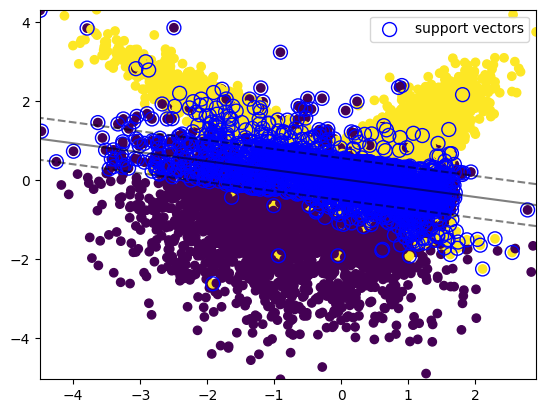

In [ ]:
def plot_svm_2D(X, y, model, plot_support=True):

    xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape([30,30])

    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])


    plt.scatter(X[:,0], X[:,1], c=y)

    if plot_support:
        plt.scatter(model.support_vectors_[:,0],
                    model.support_vectors_[:,1],
                   label='support vectors',
                   s=100,
                   linewidth=1,
                   edgecolor="blue",
                   facecolors='none')

    plt.legend()


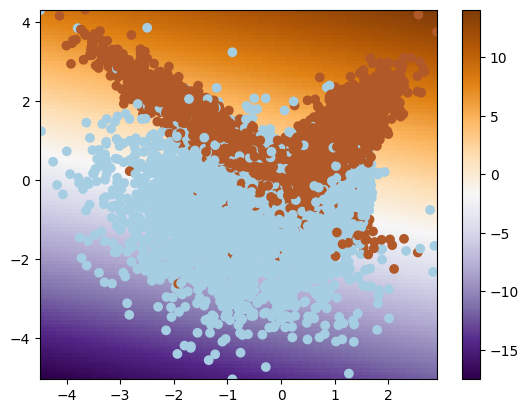

In [ ]:
def plot_logreg_2D(X, y, model):

    xx = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy)
    Z = Z.reshape((xx.shape[0], -1)).T


    image = plt.imshow(Z, interpolation='nearest',
                       extent=(xx.min(), xx.max(), yy.min(), yy.max()),
                       aspect='auto', origin='lower', cmap=plt.cm.PuOr_r)

    plt.scatter(X[:,0], X[:,1], c=y,
                cmap=plt.cm.Paired)

    plt.colorbar(image)

model = LogisticRegression().fit(X, y)
plot_logreg_2D(X, y, model)

Решим задачу классификации текста с помощью линейных моделей

In [ ]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [ ]:
!wget https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/homework/homework02/train.csv .

--2026-03-22 08:21:05--  https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/homework/homework02/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 987712 (965K) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>] 964.56K  5.59MB/s    in 0.2s    

2026-03-22 08:21:06 (5.59 MB/s) - ‘train.csv’ saved [987712/987712]

--2026-03-22 08:21:06--  http://./
Resolving . (.)... failed: No address associated with hostname.
wget: unable to resolve host address ‘.’
FINISHED --2026-03-22 08:21:06--
Total wall clock time: 0.8s
Downloaded: 1 files, 965K in 0.2s (5.59 MB/s)


In [ ]:
data = pd.read_csv('train.csv')
data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
data

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.3, random_state=42)

In [ ]:
data.isna().sum()

,0
id,0
keyword,61
location,2533
text,0
target,0


In [ ]:
data['keyword'] = data['keyword'].fillna('')
data['location'] = data['location'].fillna('')

In [ ]:
import seaborn as sns

In [ ]:
sns.countplot(data = data, x = 'target')

In [ ]:
data['keyword'].value_counts()

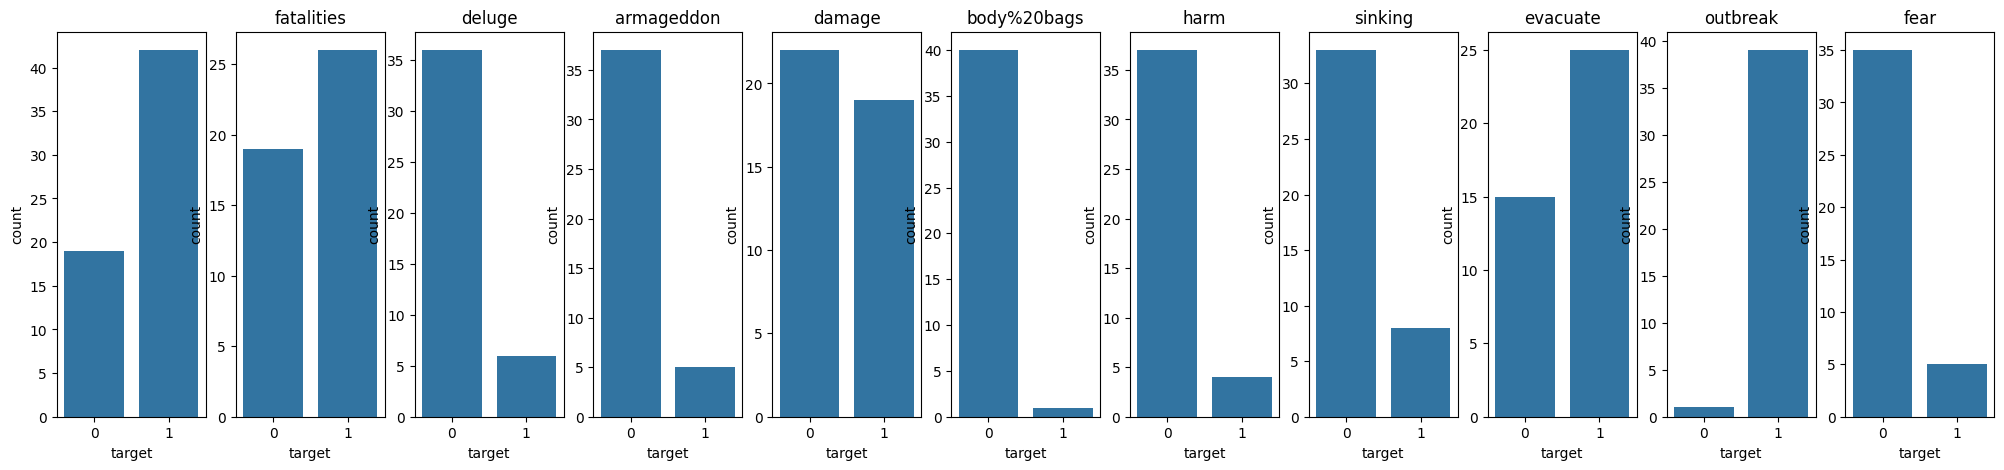

In [ ]:
popular_keywords = list(data['keyword'].value_counts().index)[0:11]
plt.figure(figsize = (25, 5))

for i in range(1, 12):
  plt.subplot(1, 11, i)
  sns.countplot(data = data[data['keyword'] == popular_keywords[i-1]], x = 'target')
  plt.title(popular_keywords[i-1])

In [ ]:
train.loc[[6590, 7122, 2769]]

,id,keyword,location,text,target
6590,9436,survivors,"Marietta, GA",Stemming from my #Cubs talk- the team rosters ...,1
7122,10203,violent%20storm,NaN,If you were the NWS wth a rotating storm w/ a ...,1
2769,3980,devastation,Atlanta g.a.,http://t.co/Gxgm1T3W0J From Devastation to Ela...,0


In [ ]:
data['Text'] = data['keyword'] + ' ' + data['location'] + ' ' + data['text']

In [ ]:
data = data.drop(['keyword', 'location', 'text'], axis = 1)

In [ ]:
data = data.reset_index(drop = True)

In [ ]:
data

,id,target,Text
0,1,1,Our Deeds are the Reason of this #earthquake...
1,4,1,Forest fire near La Ronge Sask. Canada
2,5,1,All residents asked to 'shelter in place' ar...
3,6,1,"13,000 people receive #wildfires evacuation ..."
4,7,1,Just got sent this photo from Ruby #Alaska a...
...,...,...,...
7608,10869,1,Two giant cranes holding a bridge collapse i...
7609,10870,1,@aria_ahrary @TheTawniest The out of control...
7610,10871,1,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. h...
7611,10872,1,Police investigating after an e-bike collide...


In [ ]:
y = data['target']

In [ ]:
from sklearn.model_selection import train_test_split

train_new, test_new, y_train, y_test = train_test_split(data.drop('target', axis = 1), y, test_size=0.3, random_state=42)

In [ ]:
train_new.loc[[6590, 7122, 2769]]

,id,Text
6590,9436,"survivors Marietta, GA Stemming from my #Cubs ..."
7122,10203,violent%20storm If you were the NWS wth a rot...
2769,3980,devastation Atlanta g.a. http://t.co/Gxgm1T3W0...


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
A = vectorizer.fit_transform(train_new['Text'])
A.shape

(5329, 18455)

In [ ]:
def contains_digit(s: str) -> bool:
    for i in s:
      if i in '0123456789':
        return True
    return False

def contains_punctuation(s: str) -> bool:
    for i in s:
      if i not in 'qwertyuiopasdfghjklzxcvbnm1234567890#@':
        return True
    return False

def is_hashtag(s: str) -> bool:
    if s[0] == '#':
      return True
    return False

def is_mention(s: str) -> bool:
    if s[0] == '@':
      return True
    return False

def investigate_vocabulary(vocabulary):
    counter_dig = 0
    counter_punc = 0
    counter_hash = 0
    counter_ment = 0
    for i in vocabulary:
      if contains_digit(i):
        counter_dig += 1
      if contains_punctuation(i):
        counter_punc += 1
      if is_hashtag(i):
        counter_hash += 1
      if is_mention(i):
        counter_ment += 1

    print('With digit:      ', counter_dig
          )
    print('With punctuation:', counter_punc
          )
    print('Hashtags:        ', counter_hash
          )
    print('Mentions:        ', counter_ment
          )

In [ ]:
dummy_vocab = {'th1nk' : 0,
               'think333' : 1,
               'think.' : 2,
               'th!nk' : 3,
               'th...nk' : 4,
               '#think' : 5,
               '@think' : 6,
               '@thinking':7,
               '@nothink' : 8,
               'think' : 9}

investigate_vocabulary(dummy_vocab)

With digit:       2
With punctuation: 3
Hashtags:         1
Mentions:         3


In [ ]:
investigate_vocabulary(
    vectorizer.vocabulary_
)

With digit:       3812
With punctuation: 0
Hashtags:         0
Mentions:         0


In [ ]:
from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer(reduce_len = True)
vectorizer = CountVectorizer(tokenizer = tokenizer.tokenize, token_pattern = None)
A = vectorizer.fit_transform(train_new['Text'])


In [ ]:
investigate_vocabulary(
    vectorizer.vocabulary_
)

With digit:       3933
With punctuation: 3682
Hashtags:         1470
Mentions:         1679


создадим кастомный токенайзер

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stopwords = nltk.corpus.stopwords.words('english')
stemmer = nltk.stem.SnowballStemmer('english')

In [ ]:
def contains_only_latin_letters(s: str) -> bool:
    for i in s:
      if i not in 'qwertyuiopasdfghjklzxcvbnm':
        return False
    return True

def is_emoji(s: str) -> bool:
    count_sk = 0
    for i in s:
      if i in 'qwertyuiopasdfghjklzxcvbnm':
        return False
      else:
        if i == '(' or i ==')':
          count_sk += 1
    if count_sk > 0:
      return True
    return False

def is_hashtag(s: str) -> bool:
    if s[0] == '#' and contains_only_latin_letters(s[1:]):
      return True
    return False

def custom_tokenizer(s: str) -> List[str]:
    s = s.lower()
    tokens = tokenizer.tokenize(s)
    ans_tokens = []
    for i in tokens:
      if (contains_only_latin_letters(i) or  is_emoji(i) or  is_hashtag(i)) and i not in stopwords:
        ans_tokens.append(i)
    for i in range(len(ans_tokens)):
      ans_tokens[i] = stemmer.stem(ans_tokens[i])
    return ans_tokens

In [ ]:
custom_tokenizer('She LOVES painting :-) #art')

['love', 'paint', ':-)', '#art']

In [ ]:
custom_tokenizer('#RockyFire Update => California Hwy. 20 clos')

['#rockyfir', 'updat', 'california', 'hwi', 'clos']

In [ ]:
data['Text'][:10].apply(lambda x: custom_tokenizer(x))

,Text
0,"[deed, reason, #earthquak, may, allah, forgiv,..."
1,"[forest, fire, near, la, rong, sask, canada]"
2,"[resid, ask, shelter, place, notifi, offic, ev..."
3,"[peopl, receiv, #wildfir, evacu, order, califo..."
4,"[got, sent, photo, rubi, #alaska, smoke, #wild..."
5,"[#rockyfir, updat, california, hwi, close, dir..."
6,"[#flood, #disast, heavi, rain, caus, flash, fl..."
7,"[top, hill, see, fire, wood]"
8,"[emerg, evacu, happen, build, across, street]"
9,"[afraid, tornado, come, area]"


обучим модель

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
vectorizer = CountVectorizer(tokenizer = custom_tokenizer, token_pattern = None)
_ = vectorizer.fit(train_new['Text'])
X_train = vectorizer.transform(train_new['Text'])
X_test = vectorizer.transform(test_new['Text'])
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
f1 = f1_score(y_pred, y_test)
print(f1)


0.7536231884057971


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer(tokenizer = custom_tokenizer, token_pattern = None)
_ = vectorizer.fit(train_new['Text'])
X_train = vectorizer.transform(train_new['Text'])
X_test = vectorizer.transform(test_new['Text'])
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
f1 = f1_score(y_pred, y_test)
print(f1)

0.7433333333333333


In [ ]:
vectorizer = TfidfVectorizer(tokenizer = custom_tokenizer, token_pattern = None)
A = vectorizer.fit_transform(data['Text'])
A.shape

(7613, 12795)

In [ ]:
vectorizer2 = TfidfVectorizer(tokenizer = custom_tokenizer, token_pattern = None, max_df = 0.9)
A2 = vectorizer2.fit_transform(data['Text'])
A2.shape

(7613, 12795)

In [ ]:
vectorizer = TfidfVectorizer(tokenizer = custom_tokenizer, token_pattern = None, max_df = 0.9)
_ = vectorizer.fit(train_new['Text'])
X_train = vectorizer.transform(train_new['Text'])
X_test = vectorizer.transform(test_new['Text'])
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
f1 = f1_score(y_pred, y_test)
print(f1)

0.7433333333333333


In [ ]:
vectorizer = TfidfVectorizer(tokenizer = custom_tokenizer, token_pattern = None, min_df = 3)
_ = vectorizer.fit(train_new['Text'])
X_train = vectorizer.transform(train_new['Text'])
X_test = vectorizer.transform(test_new['Text'])
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
f1 = f1_score(y_pred, y_test)
print(f1)

0.7437742114001107
